In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendssdirect as dss

In [2]:
a1 = pd.read_csv("./cla_data_v2/A1.csv",header=None)
a2 = pd.read_csv("./cla_data_v2/A2.csv",header=None)
clas = pd.read_csv("./cla_data_v2/CLAs.csv",header=None)
y1 = pd.read_csv("./cla_data_v2/y1.csv",header=None)
y2 = pd.read_csv("./cla_data_v2/y2.csv",header=None)
idxs = pd.read_csv("./cla_data_v2/voltUnderestimates_indexes.csv",header=None)

In [3]:
# Load data
samp_train = a1.values # 100xn matrix of EV demand samples used for training
samp_test = a2.values # 100xn matrix of new EV demand samples used for testing
v2_train = y1.values #mx 4 matrix of voltage and current measurements for training
v2_test = y2.values 
cla = clas.values # 100x1 matrix of learned cla params

# CLA test set prediction
v2_hat = samp_test@cla
print("v2 relative error: {}".format(np.linalg.norm(v2_hat-v2_test)/np.linalg.norm(v2_test)*100))

# Elementwise relative error
elementwise_rel_err = np.abs(v2_hat - v2_test)/np.abs(v2_test)

# Print shapes:
print("samp_train shape: {}".format(samp_train.shape))
print("samp_test shape: {}".format(samp_test.shape))
print("v2_train shape: {}".format(v2_train.shape))
print("v2_test shape: {}".format(v2_test.shape))
print("cla shape: {}".format(cla.shape))
print("idxs shape: {}".format(idxs.shape))
print("elementwise_rel_err shape: {}".format(elementwise_rel_err.shape))

v2 relative error: 0.01189694071379871
samp_train shape: (1810, 275)
samp_test shape: (100, 275)
v2_train shape: (1710, 88)
v2_test shape: (100, 88)
cla shape: (275, 88)
idxs shape: (88, 2)
elementwise_rel_err shape: (100, 88)


### Process CLA names and errors

In [4]:
cktfile = '/home/sam/Research/evacuationProject/data/OpenDSS Network/v1.1/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss' 
dss.run_command('redirect "{cktfile}"'.format(cktfile=cktfile))
node_names = dss.Circuit.AllNodeNames()
cla_idxs = idxs[1]
cla_timesteps = idxs[0]
cla_names = [node_names[i] for i in cla_idxs]

### Make dataframe of CLA errors and names, with phase labels 

In [29]:
# plot_idxs = [1,2]
# plot_names = [cla_names[i] for i in plot_idxs]

# Make dataframe of relative errors and node names with phase labels
m_test,n = samp_test.shape
df = pd.DataFrame(columns=['Index','Node','Phase','Relative Error','Timestep'])
for i,name in enumerate(cla_names):
    if '.1' in name:
        phase = 'A'
    elif '.2' in name:
        phase = 'B'
    elif '.3' in name:
        phase = 'C'
    else:
        phase = 'None'
    for j in range(m_test):
        # add to the dataframe by concatenating a dictionary, cla_timesteps are indexed by i.
        df = pd.concat([df,pd.DataFrame(
            {
                'Index':[i],
                'Node':[name],
                'Phase':[phase],
                'Relative Error':[elementwise_rel_err[j,i]*100],
                'Timestep':[cla_timesteps[i]]})],
                ignore_index=True)
# set dtypes
df["Timestep"] = df['Timestep'].astype(str)
df["Phase"] = df['Phase'].astype(str)
df["Node"] = df['Node'].astype(str)
df["Index"] = df['Index'].astype(int)
df["Relative Error"] = df['Relative Error'].astype(float)

# Remove all rows at timestep 59
df = df[df.Timestep != '59']

In [30]:
df

,Index,Node,Phase,Relative Error,Timestep
100,1,p1ulv52354.1,A,0.001393,60
101,1,p1ulv52354.1,A,0.011624,60
102,1,p1ulv52354.1,A,0.009002,60
103,1,p1ulv52354.1,A,0.003993,60
104,1,p1ulv52354.1,A,0.014307,60
...,...,...,...,...,...
8795,87,p1ulv56948.1,A,0.018691,69
8796,87,p1ulv56948.1,A,0.008102,69
8797,87,p1ulv56948.1,A,0.022830,69
8798,87,p1ulv56948.1,A,0.004658,69


### Plot the CLA relative errors in boxplots

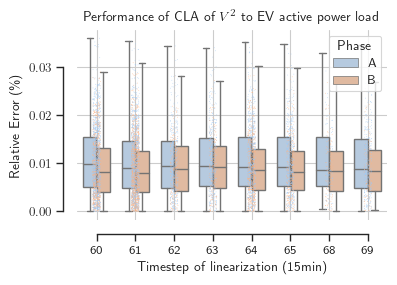

In [81]:
sns.set_style('ticks')
sns.set_context('paper')
sns.set_palette('pastel')
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style(rc={"pdf.fonttype": 3})


f, ax = plt.subplots(figsize=(4, 4/1.618))
# ax.set_yscale("log")

sns.boxplot(df,
              y='Relative Error',
              x='Timestep',
              hue='Phase',
              orient='v',
              palette='pastel',
              linewidth=1,
              width=0.7,
              saturation=0.5,
              whis=[0,100])

sns.stripplot(df,
              x='Timestep',
              y='Relative Error',
              hue='Phase',
              palette='pastel',
              size=0.5,
              linewidth=0,
              legend=False)



plt.ylabel('Relative Error (\%)')
plt.xlabel('Timestep of linearization (15min)')
plt.title('Performance of CLA of $V^2$ to EV active power load')
plt.grid()
sns.despine(trim=True,offset=10)
plt.savefig("cla_performance.pdf",bbox_inches='tight')


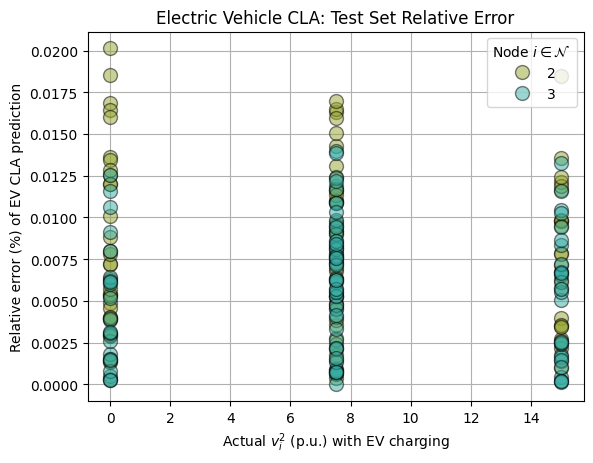

In [97]:

colors = sns.color_palette("husl", 4)
for node_ix in plot_idxs:
    plt.plot(samp_test[:,node_ix],
             elementwise_rel_err[:,node_ix]*100,
             'o',
             label="{}".format(node_ix+1),
             alpha=0.5,
             markerfacecolor=colors[node_ix],
             markeredgecolor='k',
             markersize=10)
plt.xlabel("Actual $v_i^2$ (p.u.) with EV charging")
plt.ylabel("Relative error (%) of EV CLA prediction")
plt.title("Electric Vehicle CLA: Test Set Relative Error")
plt.legend(title="Node $i \in \mathcal{N}$")
plt.grid()

In [ ]:
elementwise_rel_err = np.abs(v2_hat - v2_test)/np.abs(v2_test)
colors = sns.color_palette("husl", 4)
for node_ix in range(np.shape(elementwise_rel_err)[1]):
    plt.plot(v2_test[:,node_ix],elementwise_rel_err[:,node_ix]*100,'o',
             label="{}".format(node_ix+1),
             alpha=0.5,
             markerfacecolor=colors[node_ix],
             markeredgecolor='k',
             markersize=10)
plt.xlabel("Actual $v_i^2$ (p.u.) with EV charging")
plt.ylabel("Relative error (%) of EV CLA prediction")
plt.title("Electric Vehicle CLA: Test Set Relative Error")
plt.legend(title="Node $i \in \mathcal{N}$")
plt.grid()

$$
\min_a ||y - Xa||_1
$$

In [50]:
qsts.dss.Circuit.AllNodeNames()

NameError: name 'qsts' is not defined

Text(0, 0.5, 'Predicted test voltage')

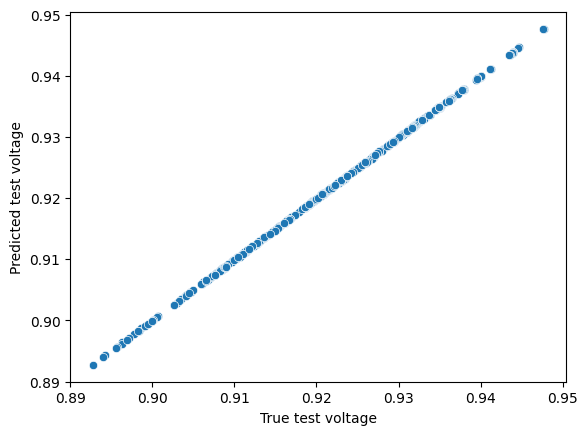

In [11]:
#Plot the results
hat_vm2_test = samp_test@cla_v2
sns.scatterplot(x=v2_test.flatten(),y=hat_vm2_test.flatten())
plt.xlabel("True test voltage")
plt.ylabel("Predicted test voltage")

In [17]:
np.linalg.norm(v2_test - samp_test@cla_v2)/np.linalg.norm(v2_test)

0.0001246894293971226

In [19]:
v2_test.shape

(100, 4)

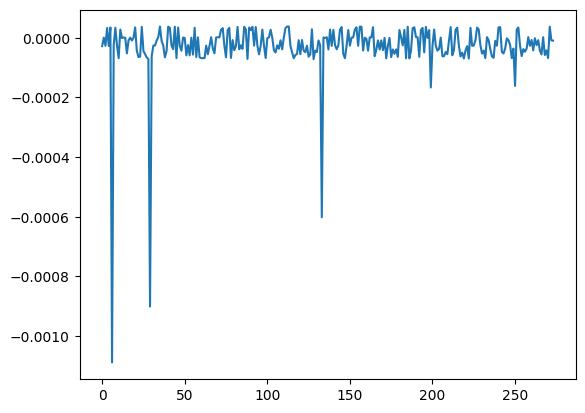

In [5]:
plt.plot(cla_v2[1:,0])

# plt.xlim([0,10])

In [6]:
samp_train[:,0]

array([1., 1., 1., ..., 1., 1., 1.])